## Neural Network Approach for Seasonal Items Forecasting of a Retail Store
## Convolutional Neural Network (CNN)

## Import libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
import seaborn as sns
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from pylab import rcParams
import itertools
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse

from datetime import datetime
from pandas import DataFrame
from pandas import concat
from pandas import Series


from tensorflow.keras.layers import Flatten, TimeDistributed,RepeatVector
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D

import os
from numpy.random import seed
from numpy.random import seed

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [5]:
data= pd.read_excel('MRP_data.xls')

## Edit columns names

In [6]:
# Lower case column names
data.columns = map(str.lower, data.columns)

#Replace spaces with '_'
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("-", "_")
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## Separate dataframe of each category

In [7]:
furniture=data.loc[data['category'] == 'Furniture']

technology=data.loc[data['category'] == 'Technology']
office=data.loc[data['category'] == 'Office Supplies']

## Aggregating sales by date

In [8]:
furniture= furniture.groupby('order_date')['sales'].sum().reset_index()

technology= technology.groupby('order_date')['sales'].sum().reset_index()
office= office.groupby('order_date')['sales'].sum().reset_index()

In [9]:
#Set index
furniture = furniture.set_index('order_date')

technology = technology.set_index('order_date')
office = office.set_index('order_date')

In [10]:
#furniture['sales']

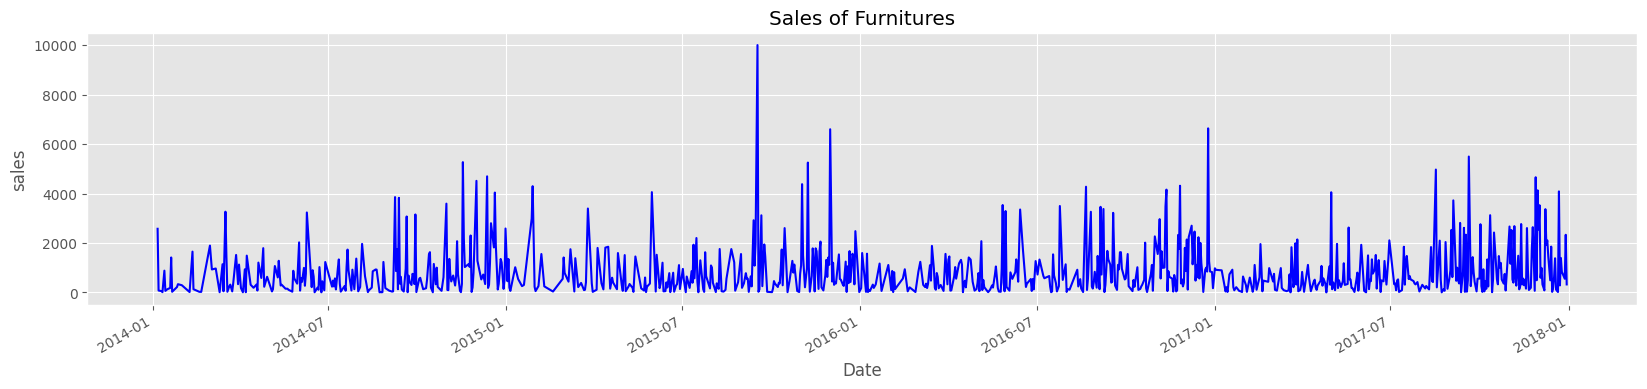

In [11]:
ax= furniture['sales'].plot(color='blue',figsize=(20,4))
ax.set_xlabel("Date")
ax.set_ylabel('sales')
ax.set_title("Sales of Furnitures")
plt.show()

In [12]:
# Using averages daily sales value - set start of the month as index
df = furniture['sales'].resample('MS').mean()
#df= avg_furniture_sales
#avg_technology_sales = technology_sales['sales'].resample('MS').mean()
#avg_office_sales = office_sales['sales'].resample('MS').mean()

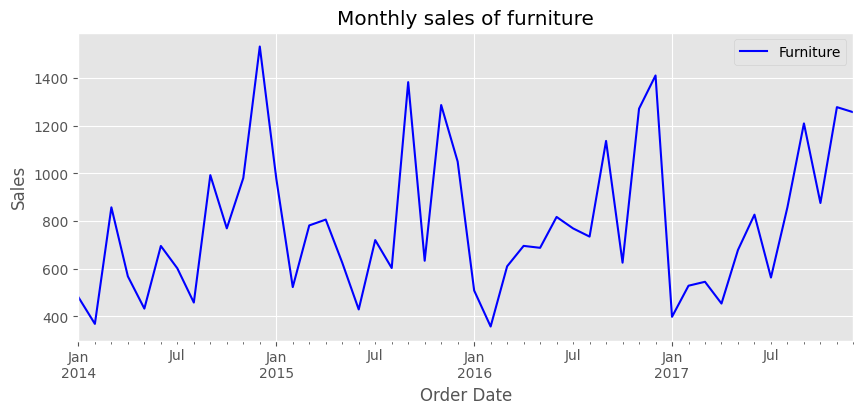

In [13]:
df.plot(figsize=(10, 4),color='blue',label = 'Furniture')

#avg_technology_sales.plot(figsize=(10, 4),color='red',label = 'Technology')

#avg_office_sales.plot(figsize=(10, 4),color='green',label = 'Office Supplies')
plt.xlabel("Order Date")
plt.ylabel('Sales')
plt.title("Monthly sales of furniture")
plt.legend()
plt.show()

### Measure of prediction accuracy

In [14]:
def performance(y_true, y_pred):
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    performance_data= {'MSE':round(mse, 2),
                      'RMSE':round(np.sqrt(mse), 2),
                       'MAPE':round(mape, 2)
                      }
    return performance_data

def performance2(y_true, y_pred):
    #y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return( print(' The MSE of forecasts is {}'.format(round(mse, 2))+
                  '\n The RMSE of forecasts is {}'.format(round(np.sqrt(mse), 2))+
                  '\n The MAPE of forecasts is {}'.format(round(mape, 2))))

## CNN

In [15]:
train, test = np.array(df[:-12]), np.array(df[-12:])
train= train.reshape(-1,1)
test= test.reshape(-1,1)

In [16]:
#Scale train and test data to [-1, 1]
scaler = MinMaxScaler()
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

In [17]:
dfcnn= np.array(df)
dfcnn= dfcnn.reshape(-1,1)
#Scale data
scaler = MinMaxScaler()
ts = scaler.fit_transform(dfcnn)

In [18]:
#Set the timestep
timestep = 12
X= []
Y=[]
raw_data=ts
for i in range(len(raw_data)- (timestep)):
    X.append(raw_data[i:i+timestep])
    Y.append(raw_data[i+timestep])


X=np.asanyarray(X)
Y=np.asanyarray(Y)
#Set the trainset
X_train = X[:24,:,:]
Y_train = Y[:24]
#Set the testset
X_test = X[24:,:,:]
Y_test= Y[24:]

In [19]:
#define model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu', input_shape=(12, 1)))
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu'))
cnn_model.add(Conv1D(filters=128, kernel_size=2, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(100, activation='relu'))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')


# fit model
cnn_model.fit(X_train, Y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 [==============================] - 1s 1s/step - loss: 0.1959
Epoch 2/200
1/1 [==============================] - 0s 16ms/step - loss: 0.1322
Epoch 3/200
1/1 [==============================] - 0s 14ms/step - loss: 0.0906
Epoch 4/200
1/1 [==============================] - 0s 16ms/step - loss: 0.0712
Epoch 5/200
1/1 [==============================] - 0s 15ms/step - loss: 0.0849
Epoch 6/200
1/1 [==============================] - 0s 13ms/step - loss: 0.0867
Epoch 7/200
1/1 [==============================] - 0s 12ms/step - loss: 0.0729
Epoch 8/200
1/1 [==============================] - 0s 12ms/step - loss: 0.0620
Epoch 9/200
1/1 [==============================] - 0s 12ms/step - loss: 0.0609
Epoch 10/200
1/1 [==============================] - 0s 12ms/step - loss: 0.0639
Epoch 11/200
1/1 [==============================] - 0s 11ms/step - loss: 0.0642
Epoch 12/200
1/1 [==============================] - 0s 17ms/step - loss: 0.0606
Epoch 13/200
1/1 [==============================] -

In [20]:
# Validate data
preds = cnn_model.predict(X_test)
preds=np.array(preds)
preds=preds.reshape(-1,1)
preds = scaler.inverse_transform(preds)


Y_test=np.asanyarray(Y_test)
Y_test=Y_test.reshape(-1,1)
Y_test = scaler.inverse_transform(Y_test)


Y_train=np.asanyarray(Y_train)
Y_train=Y_train.reshape(-1,1)
Y_train = scaler.inverse_transform(Y_train)

1/1 [==============================] - 0s 118ms/step


In [21]:
cnn= performance(Y_test,preds)
cnn_predict= preds.reshape((12,))
cnn

{'MSE': 39767.02, 'RMSE': 199.42, 'MAPE': 21.56}

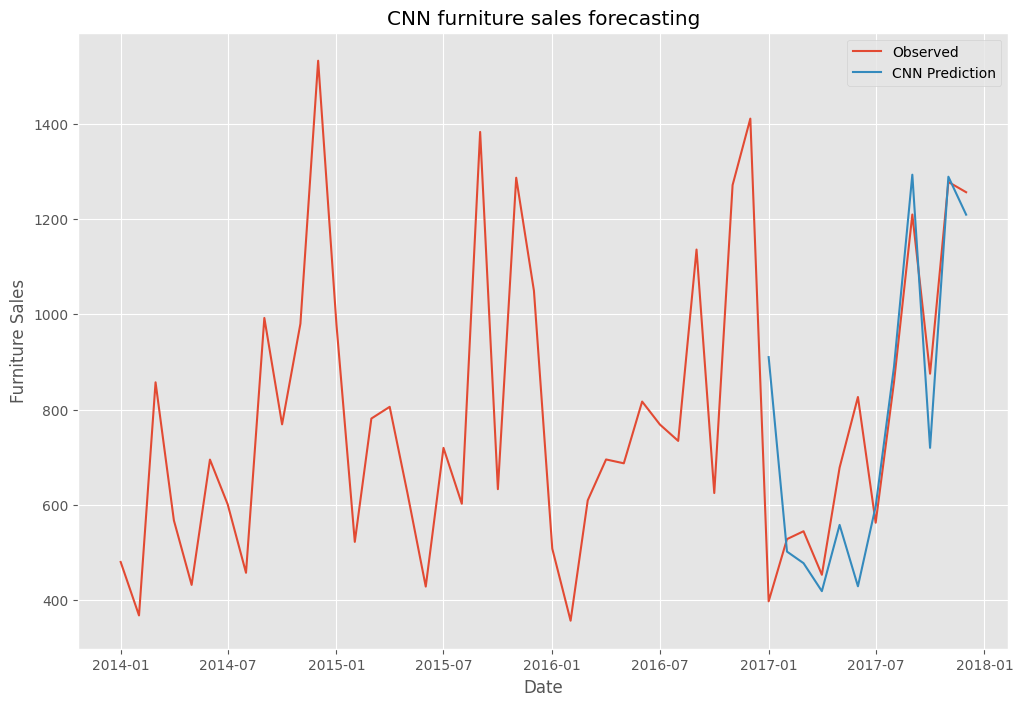

In [22]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed")
plt.plot(df[36:].index,preds,label="CNN Prediction")
plt.title('CNN furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()